# BC01 — Infrastructure de données (notebook de démonstration)

## De quoi parle-t-on ?

Imaginez qu'on vous demande : *« Est-ce qu'il va y avoir des hirondelles à Lille la semaine
prochaine ? »* Pour répondre sérieusement, il ne suffit pas de deviner — il faut des **données** :
des observations passées d'hirondelles, et la météo qui allait avec. Si on remarque que les
hirondelles arrivent toujours quand il fait plus de 12°C, on peut commencer à faire des prédictions
raisonnables.

C'est exactement notre projet : on veut apprendre à un ordinateur à prédire, **semaine par semaine
et zone par zone** dans le Nord-Pas-de-Calais, si 4 espèces d'oiseaux migrateurs seront **présentes
ou absentes**, en se basant sur la météo. En apprentissage automatique (*Machine Learning*), on
appelle ça un problème de **classification** : on range chaque situation dans une catégorie
(« présent » ou « absent »), plutôt que de prédire un nombre précis. C'est ce que les blocs BC03 et
BC04 feront plus tard.

## Pourquoi ce bloc (BC01) avant tout le reste ?

Le problème, c'est que les données qu'on va récupérer sur Internet ne ressemblent **pas du tout**
à ce dont on a besoin. Une donnée brute, c'est par exemple : *« Le 12 avril 2023, quelqu'un a vu
une Hirondelle rustique à telle latitude/longitude. »* C'est un point isolé, presque anecdotique.
Ce qu'on veut, c'est un grand tableau bien rangé, avec une ligne par semaine et par zone, qui dit
clairement « présent » ou « absent ». **C'est tout le travail de ce bloc BC01** : partir de
signalements épars et construire, étape par étape, ce tableau bien rangé — la matière première dont
BC02, BC03 et BC04 auront besoin.

## Comment suivre ce notebook

On va avancer en 5 étapes, chacune expliquée avant qu'on l'exécute :

1. **Section 2 — Acquisition** : on va chercher les données brutes sur Internet (observations
   d'oiseaux via l'API **GBIF**, météo via l'API **Open-Meteo**).
2. **Section 3 — Nettoyage** : on retire ce qui est invalide ou en double.
3. **Section 4 — Restructuration** : l'étape la plus importante, celle qui transforme des points
   épars en un vrai tableau « présence/absence par semaine ».
4. **Section 5 — Météo** : on nettoie la météo en parallèle.
5. **Section 6 — Sauvegarde** : on écrit les fichiers finaux, prêts pour la suite du projet.

**Un repère à garder en tête** : on part d'environ 40 000 signalements individuels, et on va
terminer avec un tableau d'environ 680 000 lignes. Ça peut paraître étrange qu'on ait *plus*
de lignes à l'arrivée qu'au départ — c'est normal, et la section 4 explique pourquoi.

Ce notebook n'invente rien : il utilise le vrai code du bloc (les fichiers `acquisition.py` et
`nettoyage.py`), le même que celui utilisé en production par `run.py`. On l'exécute simplement
morceau par morceau, avec des explications, pour bien voir ce qui se passe à chaque étape.

## 0. Préparation : rendre le code du projet importable

Avant de commencer, un point technique à comprendre. Ce notebook se trouve dans le dossier du bloc
BC01, mais il a besoin d'utiliser du code écrit ailleurs dans le projet (le dossier `commun/`, à la
racine, qui contient des réglages partagés par tous les blocs). Or, par défaut, Python ne sait
regarder que dans le dossier où il se trouve, un peu comme si vous cherchiez un livre uniquement
sur l'étagère devant vous, sans savoir qu'il y en a d'autres dans la pièce.

La cellule ci-dessous résout ça : elle dit à Python « regarde aussi dans le dossier racine du
projet » (`sys.path.insert`). Une fois cette étape faite une bonne fois pour toutes, on peut
importer `commun.config` et les fichiers `acquisition.py` / `nettoyage.py` de ce bloc normalement,
comme n'importe quel autre module Python.

Une fois l'environnement prêt, on peut regarder précisément *ce qu'on va demander* aux services en
ligne (API) dont on va se servir.

In [1]:
import sys
from pathlib import Path

# Remonte jusqu'au dossier qui contient le package commun/ (racine du projet)
_racine = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "commun").is_dir())
sys.path.insert(0, str(_racine))

import pandas as pd
import matplotlib.pyplot as plt

# figures matplotlib rendues directement dans le notebook
%matplotlib inline

from commun.config import (
    ESPECES,
    ZONE_GEOGRAPHIQUE,
    REPERTOIRE_DONNEES_BRUTES,
    REPERTOIRE_DONNEES_TRAITEES,
)
from acquisition import AcquisiteurGBIF, AcquisiteurMeteo, executer_acquisition
from nettoyage import NettoyeurObservations, AggregeurTemporel, traiter_meteo, executer_nettoyage

# Logs moins verbeux : on garde INFO, on masque les DEBUG de pagination
from loguru import logger
logger.remove()
logger.add(sys.stderr, level="INFO")

print("Racine du projet :", _racine)

Racine du projet : C:\Users\rasmi\Projects\projet_rncp\oiseaux_migrateurs_npdc


## 1. Ce qu'on va chercher

Avant de télécharger quoi que ce soit, il faut répondre à deux questions simples : **où** regarder,
et **quoi** regarder.

- **Où ?** On délimite le Nord-Pas-de-Calais avec une **bounding box** (littéralement « boîte
  englobante ») : c'est juste un rectangle tracé sur la carte, défini par 4 nombres — une latitude
  minimale et maximale, une longitude minimale et maximale. C'est la manière la plus simple de dire
  à un programme « je ne veux que les points qui tombent dans ce rectangle-là ».
- **Quoi ?** On liste les 4 espèces migratrices étudiées. Chacune a un **code GBIF** (`code_gbif`)
  — un numéro d'identification unique, un peu comme un numéro de sécurité sociale, mais pour une
  espèce animale plutôt qu'une personne. C'est ce numéro, et non le nom en français, qu'on envoie
  aux API : les ordinateurs préfèrent les identifiants uniques aux noms, qui peuvent avoir des
  variantes ou des fautes d'orthographe.
- **Quand ?** On se limite à la période **2019-2024**. Ce n'est pas arbitraire : une première
  exploration de GBIF a montré que la base ne contient quasiment aucune observation de ces 4
  espèces dans la région avant 2019 (trop peu de contributeurs actifs à l'époque). Commencer
  plus tôt reviendrait à remplir la future grille de milliers de lignes « absence » pour des
  années où, en réalité, personne n'a rien noté — on y revient en section 4.

On note aussi les mois d'arrivée et de départ attendus pour chaque espèce. Par exemple, la
**Cigogne blanche** (`code_gbif = 2481912`) est censée arriver en mars-avril et repartir en
août-septembre. Ce n'est pas utilisé tout de suite, mais on s'en resservira en BC02/BC03 comme
repère : si le modèle prédit des cigognes en plein hiver, ce sera un signal que quelque chose ne va
pas.

Exécutons la cellule suivante pour voir ces informations sous forme de tableau.

In [2]:
print(ZONE_GEOGRAPHIQUE)
pd.DataFrame(ESPECES).T[["nom_francais", "nom_scientifique", "code_gbif", "mois_arrivee", "mois_depart"]]

BoundingBoxNPdC(latitude_min=49.5, latitude_max=51.5, longitude_min=1.5, longitude_max=4.0, centre_latitude=50.5, centre_longitude=2.75, nom_region='Nord-Pas-de-Calais')


,nom_francais,nom_scientifique,code_gbif,mois_arrivee,mois_depart
hirondelle_rustique,Hirondelle rustique,Hirundo rustica,9515886,"[4, 5]","[9, 10]"
cigogne_blanche,Cigogne blanche,Ciconia ciconia,2481912,"[3, 4]","[8, 9]"
martinet_noir,Martinet noir,Apus apus,5228676,"[5, 6]","[8, 9]"
bergeronnette_printaniere,Bergeronnette printaniere,Motacilla alba,9687165,"[3, 4]","[10, 11]"


## 2. Acquisition — étape par étape

**Petit rappel sur ce qu'est une API**, pour ceux qui découvrent : une API (*Application
Programming Interface*) est un service en ligne qui répond à des demandes précises. C'est un peu
comme un serveur de restaurant : vous ne rentrez pas en cuisine préparer votre plat vous-même, vous
passez commande selon un menu précis (« donne-moi les observations de telle espèce, dans telle
zone, sur telle période ») et le serveur (l'API) vous rapporte le résultat. Ici, on utilise deux
API : **GBIF** pour les observations d'oiseaux, et **Open-Meteo** pour la météo.

**Notre stratégie :** on ne se lance pas directement dans le téléchargement des 4 espèces. On teste
d'abord avec **une seule espèce**, pour vérifier que la commande passe bien et que la réponse
ressemble à ce qu'on attend. C'est une habitude à prendre : mieux vaut découvrir un problème sur un
petit essai rapide que sur un téléchargement qui prend plusieurs minutes.

### 2a. Une seule espèce, pour voir la réponse de l'API GBIF

La méthode `AcquisiteurGBIF.telecharger_observations_espece` fait le travail suivant :
- elle **pagine** l'appel : au lieu de demander toutes les données d'un coup (ce que l'API
  refuserait), elle les demande par paquets de 300, comme on tournerait les pages d'un livre une
  par une plutôt que de vouloir tout lire en une seule fois ;
- elle **filtre géographiquement** grâce à la bounding box définie en section 1 ;
- elle **réessaie automatiquement** en cas d'erreur passagère du serveur (par exemple une erreur
  « 503 », qui veut dire « le serveur est momentanément surchargé, réessayez plus tard »).

In [3]:
gbif = AcquisiteurGBIF()
df_hirondelle = gbif.telecharger_observations_espece(
    "hirondelle_rustique", ESPECES["hirondelle_rustique"]
)
print("Colonnes :", list(df_hirondelle.columns))
print("Nombre d'observations :", len(df_hirondelle))
df_hirondelle.head()

2026-09-03 15:36:28.440 | INFO     | acquisition:telecharger_observations_espece:72 - Telechargement Hirondelle rustique...


2026-09-03 15:37:58.074 | INFO     | acquisition:telecharger_observations_espece:106 -   10000 observations telechargees pour Hirondelle rustique


Colonnes : ['espece', 'nom_scientifique', 'date_observation', 'latitude', 'longitude', 'precision_coordinate', 'pays', 'source', 'id_gbif']
Nombre d'observations : 10000


,espece,nom_scientifique,date_observation,latitude,longitude,precision_coordinate,pays,source,id_gbif
0,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-08,51.400000,3.90000,5000.0,Netherlands,GBIF,4881884490
1,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-02,51.400000,3.90000,5000.0,Netherlands,GBIF,4885294867
2,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-05,51.400000,3.90000,5000.0,Netherlands,GBIF,4885677627
3,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-08,51.400000,3.90000,5000.0,Netherlands,GBIF,4887159864
4,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-03-29T17:00,50.509927,2.59639,7.0,France,GBIF,4606830326


**Décortiquons le résultat affiché ci-dessus :**

- **10 000 observations, pile.** Ce n'est pas une coïncidence : le fichier `commun/config.py`
  contient un réglage `LIMITE_RESULTATS_PAR_ESPECE = 10000` qui **plafonne volontairement** le
  nombre de résultats téléchargés par espèce. On aurait pu régler ce chiffre plus haut pour
  récupérer l'historique complet de GBIF, mais pour une démonstration, un plafond raisonnable
  suffit et évite un téléchargement trop long.
- **La colonne `pays` affiche parfois `Netherlands`**, alors qu'on étudie le Nord-Pas-de-Calais.
  Est-ce une erreur ? Non ! On filtre par **géométrie** (le rectangle défini en section 1), pas par
  frontière administrative. Et ce rectangle déborde légèrement aux Pays-Bas et en Belgique, tout
  près de la frontière. C'est voulu, et même logique : un oiseau ne sait pas qu'il traverse une
  frontière, et un point situé à 500 mètres de la Belgique reste tout à fait pertinent pour étudier
  le climat de la région.

Maintenant qu'on a vérifié que l'API répond correctement, avec les bonnes colonnes et un vrai
nombre de résultats, on peut passer en confiance au téléchargement complet.

### 2b. L'acquisition complète (les 4 espèces + la météo)

Rien de nouveau conceptuellement : `executer_acquisition()` répète exactement ce qu'on vient de
faire pour l'Hirondelle rustique, mais pour les 4 espèces (jusqu'à 10 000 observations chacune,
donc jusqu'à 40 000 au total), en ajoutant la météo journalière pour la même période (2019-2024,
soit 2 192 jours).

Un détail pratique utile à connaître : si les fichiers ont déjà été téléchargés une première fois
et existent sur le disque, cette étape est **automatiquement sautée** — pas besoin de re-taper à
la porte de l'API à chaque fois qu'on relance le notebook. Pour forcer un nouveau téléchargement
(par exemple si les données ont changé), il suffit de passer `forcer=True`.

In [4]:
executer_acquisition(forcer=False)

df_brut = pd.read_csv(REPERTOIRE_DONNEES_BRUTES / "observations_gbif.csv")
df_meteo_brut = pd.read_csv(REPERTOIRE_DONNEES_BRUTES / "meteo_npdc.csv")
print(f"observations_gbif.csv : {len(df_brut):>7} lignes")
print(f"meteo_npdc.csv        : {len(df_meteo_brut):>7} lignes")
df_brut.head()

2026-09-03 15:37:58.209 | INFO     | acquisition:executer_acquisition:182 - Donnees brutes deja presentes sur disque -> telechargement saute.


2026-09-03 15:37:58.211 | INFO     | acquisition:executer_acquisition:183 -   (utiliser --forcer-telechargement pour re-telecharger depuis GBIF/Open-Meteo)


observations_gbif.csv :   40000 lignes
meteo_npdc.csv        :    2192 lignes


,espece,nom_scientifique,date_observation,latitude,longitude,precision_coordinate,pays,source,id_gbif
0,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-08,51.400000,3.90000,5000.0,Netherlands,GBIF,4881884490
1,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-02,51.400000,3.90000,5000.0,Netherlands,GBIF,4885294867
2,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-05,51.400000,3.90000,5000.0,Netherlands,GBIF,4885677627
3,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-08,51.400000,3.90000,5000.0,Netherlands,GBIF,4887159864
4,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-03-29T17:00,50.509927,2.59639,7.0,France,GBIF,4606830326


## 3. Nettoyage (ETL) — l'effet de chaque filtre

On vient de récupérer 40 000 signalements bruts. Avant de les utiliser, il faut les **nettoyer** —
un peu comme on trierait des photos de vacances avant de les ranger dans un album : on retire les
photos floues, en double, ou qui ne correspondent pas au bon voyage. Concrètement, on va vérifier 3
choses : y a-t-il des coordonnées manquantes ? des points en dehors de notre zone d'étude ? des
signalements comptés plusieurs fois (des **doublons**) ?

*(Petit aparté sur le sigle ETL, qu'on croise souvent en science des données : ça veut dire
Extract-Transform-Load, soit « extraire, transformer, charger » — exactement les 3 grandes étapes
de ce bloc BC01, de l'acquisition à la sauvegarde finale.)*

On a déjà vu en section 1 que l'API GBIF filtre elle-même les résultats côté serveur. Alors
pourquoi refaire ces vérifications ici ? Parce qu'on ne fait jamais une confiance aveugle à une
source de données externe : une panne, un changement dans l'API, ou une autre source de données à
l'avenir pourrait laisser passer des lignes invalides. Ce filtre est notre filet de sécurité.

La méthode `NettoyeurObservations.charger_et_nettoyer()` fait tout ça en 5 étapes d'un coup, mais
n'affiche qu'un total global à la fin — une boîte noire un peu frustrante si on veut comprendre.
Alors, pour apprendre, on va d'abord appeler les 3 premières étapes **une par une, à la main**, et
compter précisément combien de lignes chacune retire.

In [5]:
nettoyeur = NettoyeurObservations()
df = df_brut.copy()
print(f"Départ                                   : {len(df):>7}")

df = nettoyeur._supprimer_valeurs_nulles(df)
print(f"Après suppression lat/lon/date manquants : {len(df):>7}")

df = nettoyeur._valider_coordonnees(df)
print(f"Après validation des coordonnées (bbox)  : {len(df):>7}")

df = nettoyeur._filtrer_region(df)
print(f"Après filtrage sur la région NPDC        : {len(df):>7}")

Départ                                   :   40000
Après suppression lat/lon/date manquants :   40000
Après validation des coordonnées (bbox)  :   40000
Après filtrage sur la région NPDC        :   40000


**On observe : 40 000 → 40 000 → 40 000.** Les 3 premiers filtres ne retirent **rien du tout**.
Est-ce qu'ils servent à quelque chose alors ? Oui, et c'est important de comprendre pourquoi : ils
ne retirent rien *cette fois-ci* parce que l'API GBIF avait déjà fait le travail en amont (section
2). Mais on les garde quand même dans le code, comme une **ceinture de sécurité** : elle ne sert à
rien tant qu'il n'y a pas d'accident, mais le jour où la source de données change de comportement,
elle nous protégera. Un filtre inutile aujourd'hui vaut mieux qu'un bug silencieux demain.

**Pour la suite, plus besoin de dérouler à la main.** Il reste deux étapes qu'on n'a pas encore
faites : uniformiser le format des dates, puis retirer les **doublons** — c'est-à-dire les lignes
qui décrivent en réalité le même signalement, reconnaissables parce qu'elles partagent le même
`id_gbif` (un peu comme deux exemplaires identiques du même ticket de caisse). Ça peut arriver par
exemple quand un même signalement est republié par un jeu de données qui agrège plusieurs sources.
Ces deux dernières étapes sont incluses dans la méthode complète `charger_et_nettoyer` — celle
utilisée par `run.py` en production. On l'appelle directement ci-dessous et on regarde le résultat
final.

In [6]:
df_propre = nettoyeur.charger_et_nettoyer(REPERTOIRE_DONNEES_BRUTES / "observations_gbif.csv")
print("Observations nettoyées :", len(df_propre))
print("Espèces                :", df_propre["espece"].nunique())
print("Période                :", df_propre["date_observation"].min().date(),
      "->", df_propre["date_observation"].max().date())
df_propre.head()

2026-09-03 15:37:58.365 | INFO     | nettoyage:charger_et_nettoyer:32 - Chargement observations : observations_gbif.csv


2026-09-03 15:37:58.419 | INFO     | nettoyage:charger_et_nettoyer:43 -   Observations initiales : 40000


2026-09-03 15:37:58.428 | INFO     | nettoyage:charger_et_nettoyer:49 -   Apres suppression nulls : 40000 (-0)


2026-09-03 15:37:58.433 | INFO     | nettoyage:charger_et_nettoyer:52 -   Apres validation coords : 40000 (-0)


2026-09-03 15:37:58.437 | INFO     | nettoyage:charger_et_nettoyer:55 -   Apres filtrage region : 40000


2026-09-03 15:37:58.559 | INFO     | nettoyage:charger_et_nettoyer:67 -   Apres suppression doublons : 39986 (-0)


Observations nettoyées : 39986
Espèces                : 4
Période                : 2019-01-01 -> 2024-12-31


,espece,nom_scientifique,date_observation,latitude,longitude,precision_coordinate,pays,source,id_gbif
0,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-08 00:00:00,51.400000,3.90000,5000.0,Netherlands,GBIF,4881884490
1,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-02 00:00:00,51.400000,3.90000,5000.0,Netherlands,GBIF,4885294867
2,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-05 00:00:00,51.400000,3.90000,5000.0,Netherlands,GBIF,4885677627
3,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-01-08 00:00:00,51.400000,3.90000,5000.0,Netherlands,GBIF,4887159864
4,hirondelle_rustique,"Hirundo rustica Linnaeus, 1758",2024-03-29 17:00:00,50.509927,2.59639,7.0,France,GBIF,4606830326


**On obtient 39 986 observations, soit 14 doublons retirés** — cohérent avec ce qu'on pouvait
attendre. La **période va de 2019 à 2024**, exactement ce qu'on a demandé à l'API
(`ANNEE_DEBUT = 2019` dans la configuration).

Pourquoi commencer en 2019, et pas plus tôt ? Parce qu'une première exploration l'a montré :
GBIF ne recense presque aucun signalement de ces 4 espèces dans cette zone avant 2019
(probablement moins de contributeurs actifs sur le terrain à l'époque). On aurait pu demander
« depuis 2015 » quand même — l'API aurait répondu sans erreur — mais on se serait retrouvé
avec quatre années entièrement vides. On verra en section 4 pourquoi c'était une mauvaise
idée : ces années sans donnée ne signifient pas « les oiseaux étaient absents », et les
mélanger au reste fausserait tout l'équilibre du tableau final. C'est le genre de décision
qu'on ne prend qu'après avoir vraiment regardé ses données, et pas seulement lu la
documentation d'une API.

### Contrôle visuel : distribution mensuelle des observations

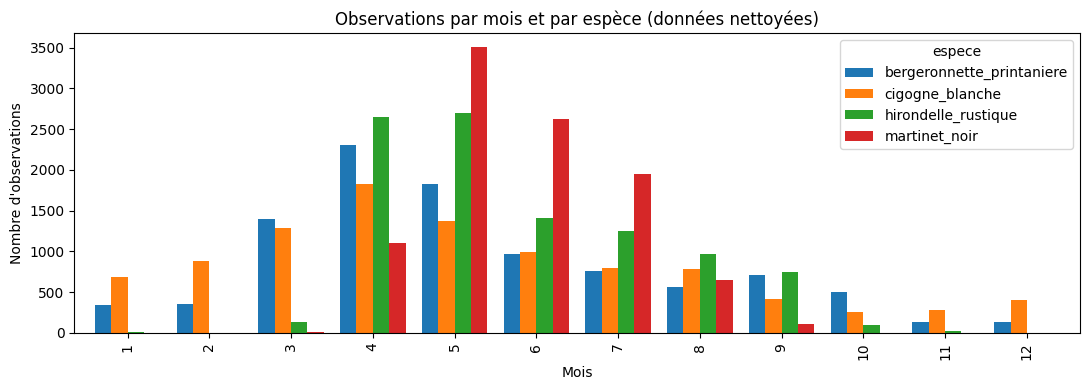

In [7]:
df_propre["mois"] = pd.to_datetime(df_propre["date_observation"]).dt.month
(df_propre.groupby(["mois", "espece"]).size().unstack()
    .plot(kind="bar", figsize=(11, 4), width=0.8))
plt.title("Observations par mois et par espèce (données nettoyées)")
plt.xlabel("Mois")
plt.ylabel("Nombre d'observations")
plt.tight_layout()
plt.show()

## 4. La transformation clé : la grille hebdomadaire présence/absence

C'est le cœur de tout le bloc BC01 — l'étape la plus importante à bien comprendre.

**Le problème.** Revenons à la question du départ : on veut savoir, pour chaque semaine et chaque
zone, si une espèce est présente ou absente. Mais nos 39 986 observations sont **éparses** : chaque
ligne représente un signalement isolé, là où quelqu'un a eu la chance (et l'envie) de regarder.
Il n'existe **aucune ligne** pour les endroits et moments où personne n'a rien observé. Or, une
absence est une information tout aussi précieuse qu'une présence : si on ne garde que les
observations positives, on apprendrait à un modèle que les oiseaux sont *toujours* là, ce qui est
faux.

**Une image pour comprendre.** Imaginez un immense damier posé sur la carte du Nord-Pas-de-Calais,
où chaque case représente une semaine, une petite zone géographique, et une espèce précise. Le
travail de cette section est de remplir **chaque case** du damier avec un 1 (« vu au moins une fois
cette semaine-là, dans cette case ») ou un 0 (« pas vu ») — même les cases où on n'a aucune
observation, qui deviennent alors des 0.

**Concrètement**, la fonction `AggregeurTemporel.creer_grille_hebdomadaire` fait deux choses :

1. Elle **découpe l'espace en petites cases** (des « mailles ») de 0,1° de large — soit environ
   11 km sur 7 km à cette latitude. C'est nécessaire car deux observations n'ont presque jamais
   exactement les mêmes coordonnées GPS au mètre près ; il faut donc les regrouper par petite zone
   pour pouvoir les compter ensemble.
2. Elle **construit toutes les cases possibles du damier**, puis vérifie pour chacune s'il existe
   au moins une observation dedans (→ `presence = 1`) ou aucune (→ `presence = 0`).

On s'attend donc à un très grand tableau : 6 années (2019-2024) × 52 semaines × 4 espèces ×
(autant de cases géographiques que nos données en couvrent). Exécutons la cellule ci-dessous pour voir si ce calcul
correspond bien à la réalité, et regardons surtout l'équilibre entre présences et absences.

In [8]:
grille = AggregeurTemporel.creer_grille_hebdomadaire(df_propre)
print("Dimensions de la grille :", grille.shape)
print("\nÉquilibre des classes :")
print(grille["presence"].value_counts())
print(f"\n-> {grille['presence'].mean()*100:.1f} % de présences (fort déséquilibre, à garder en tête pour BC03)")
grille.head()

2026-09-03 15:37:59.144 | INFO     | nettoyage:creer_grille_hebdomadaire:97 - Creation grille hebdomadaire...


2026-09-03 15:38:00.123 | INFO     | nettoyage:creer_grille_hebdomadaire:127 -   Grille creee : 681408 lignes


2026-09-03 15:38:00.130 | INFO     | nettoyage:creer_grille_hebdomadaire:128 -   Equilibre classes : {0: 665505, 1: 15903}


Dimensions de la grille : (681408, 7)

Équilibre des classes :
presence
0    665505
1     15903
Name: count, dtype: int64

-> 2.3 % de présences (fort déséquilibre, à garder en tête pour BC03)


,annee,semaine,espece,lat_discrete,lon_discrete,nombre_observations,presence
0,2019,1,hirondelle_rustique,51.4,3.9,0.0,0
1,2019,1,hirondelle_rustique,51.4,2.6,0.0,0
2,2019,1,hirondelle_rustique,51.4,3.5,0.0,0
3,2019,1,hirondelle_rustique,51.4,3.8,0.0,0
4,2019,1,hirondelle_rustique,51.4,4.0,0.0,0


**Vérifions notre calcul, comme on vérifierait un exercice de maths.** On attendait
6 ans × 52 semaines × 4 espèces × (nombre de cases géographiques). Le résultat affiché est
681 408 lignes. En faisant le calcul à l'envers : 6 × 52 × 4 = 1 248, et
681 408 ÷ 1 248 = **546**. Il y a donc 546 cases géographiques différentes dans nos données, et
le compte tombe rond — c'est la preuve que la grille fait exactement ce qu'on attendait d'elle,
rien de plus, rien de moins.

**Maintenant, un point important à ne pas balayer sous le tapis.** On voit que seulement **2,3 %**
des cases valent « présence » : c'est ce qu'on appelle un **déséquilibre de classes**, très courant
en Machine Learning, et qui complique l'apprentissage d'un modèle (un modèle paresseux pourrait
répondre « toujours absent » et avoir quand même 97,7 % de bonnes réponses, sans rien avoir appris
d'utile).

Ce déséquilibre-ci est **réel**, ce n'est pas un artefact : sur une semaine donnée, une espèce
n'est effectivement présente que dans une poignée de mailles, et absente partout ailleurs. C'est
justement pour ne pas l'aggraver artificiellement qu'on a borné la période à 2019 (section 3) :
garder 2015-2018, sans aucune observation, aurait ajouté ~40 % de lignes « absence » qui
n'auraient rien appris au modèle, sinon à répondre « absent » encore plus souvent. Il reste tout
de même une nuance à transmettre à la suite : l'effort d'observation grandit d'année en année
(2019 est encore clairsemée, avec 0,4 % de présences, contre 4 % en 2024). BC02 devra le
signaler, et BC03 devra en tenir compte (pondération des classes, lecture prudente de
l'accuracy).

## 5. La météo

On a maintenant notre damier de présence/absence — mais il répond seulement à « quand et où »,
pas à « pourquoi ». Pour prédire, il faut une **variable explicative** : quelque chose qu'on pense
capable d'influencer la présence des oiseaux. Ici, c'est la météo (température, pluie, vent...).

`traiter_meteo` fait un nettoyage classique : elle donne le bon type à chaque colonne (une date
reste une date, une température reste un nombre, pas du texte), trie les lignes par date, et
retire les doublons. On termine en affichant un résumé statistique (`describe()`) — moyenne,
minimum, maximum de chaque variable — simplement pour vérifier que les chiffres sont plausibles
pour un climat du Nord de la France (par exemple, une température maximale moyenne autour de 15°C
sur ces 6 ans, ou une humidité assez élevée, typique d'un climat océanique). Si on voyait une
température moyenne de 40°C, on saurait tout de suite qu'il y a un problème quelque part.

**Une question légitime à se poser : pourquoi ne pas directement combiner cette météo avec la
grille des oiseaux, tout de suite ?** Parce que les deux tableaux n'ont pas le même niveau de
détail (on dit la même **granularité**) : la grille est **hebdomadaire et par petite zone**, alors
que la météo est **quotidienne et pour toute la région**. Combiner les deux demande d'abord de
regrouper la météo par semaine — une étape qui sera faite plus tard, dans BC02/BC03. Le rôle de
BC01 s'arrête ici : livrer deux fichiers propres, prêts à être assemblés.

In [9]:
df_meteo = traiter_meteo(REPERTOIRE_DONNEES_BRUTES / "meteo_npdc.csv")
print("Jours de météo :", len(df_meteo))
df_meteo.describe().round(1)

2026-09-03 15:38:00.175 | INFO     | nettoyage:traiter_meteo:160 - Donnees meteo nettoyees : 2192 lignes


Jours de météo : 2192


,date,temperature_max,temperature_min,temperature_moyenne,precipitation_sum,vent_max,humidite_moyenne,pression_moyenne
count,2192,2192.0,2192.0,2192.0,2192.0,2192.0,2192.0,2192.0
mean,2021-12-31 12:00:00,15.4,8.0,11.6,2.2,21.7,78.3,1015.9
min,2019-01-01 00:00:00,-2.9,-7.4,-4.9,0.0,5.5,38.0,975.3
25%,2020-07-01 18:00:00,10.4,4.1,7.4,0.0,15.5,72.0,1010.1
50%,2021-12-31 12:00:00,15.1,8.1,11.3,0.3,20.3,79.0,1016.4
75%,2023-07-02 06:00:00,20.4,12.4,16.4,2.7,26.8,86.0,1022.6
max,2024-12-31 00:00:00,38.2,22.3,29.2,35.4,62.5,98.0,1047.6
std,NaN,6.7,5.4,5.8,3.8,8.4,9.5,10.2


## 6. Écriture des livrables

Jusqu'ici, on a tout rejoué **à la main**, étape par étape, pour bien comprendre chaque
transformation. `executer_nettoyage()` est la version « tout-en-un » : c'est exactement la fonction
qu'appelle `run.py` en production, sans qu'un humain ait besoin d'exécuter chaque cellule une par
une. Elle refait dans l'ordre le nettoyage (section 3), la grille (section 4) et la météo
(section 5), puis **sauvegarde** les résultats sur le disque, au format **Parquet** — un format de
fichier compact et rapide à relire, mieux adapté que le CSV pour de gros tableaux de données (il
prend moins de place et conserve le type de chaque colonne).

Pourquoi relancer tout le pipeline alors qu'on vient déjà de le faire à la main ? Pour vérifier
qu'on retrouve **exactement les mêmes chiffres** qu'en sections 3 et 4 (39 986 observations,
681 408 lignes de grille). Si c'est bien le cas, cela confirme que la version « pas à pas » qu'on
vient d'explorer et la version « production » utilisée par le reste du projet font rigoureusement
la même chose.

In [10]:
executer_nettoyage()

print("Fichiers produits :")
for f in sorted(REPERTOIRE_DONNEES_TRAITEES.glob("*.parquet")):
    print(f"  {f.name:<32} {f.stat().st_size // 1024:>5} Ko")

2026-09-03 15:38:00.211 | INFO     | nettoyage:executer_nettoyage:166 - ============================================================


2026-09-03 15:38:00.211 | INFO     | nettoyage:executer_nettoyage:167 - NETTOYAGE (ETL)


2026-09-03 15:38:00.212 | INFO     | nettoyage:executer_nettoyage:168 - ============================================================


2026-09-03 15:38:00.213 | INFO     | nettoyage:charger_et_nettoyer:32 - Chargement observations : observations_gbif.csv


2026-09-03 15:38:00.262 | INFO     | nettoyage:charger_et_nettoyer:43 -   Observations initiales : 40000


...

2026-09-03 15:38:02.021 | INFO     | nettoyage:executer_nettoyage:205 - Observations nettoyees : 39986


2026-09-03 15:38:02.024 | INFO     | nettoyage:executer_nettoyage:206 - Especes : 4


2026-09-03 15:38:02.024 | INFO     | nettoyage:executer_nettoyage:207 - Plage temporelle : 2019-01-01 00:00:00 a 2024-12-31 00:00:00


2026-09-03 15:38:02.027 | INFO     | nettoyage:executer_nettoyage:211 - Lignes de la grille presence/absence : 681408


Fichiers produits :
  grille_presence_hebdo.parquet       91 Ko
  meteo_processed.parquet             48 Ko
  observations_nettoyees.parquet     943 Ko


## Récapitulatif — ce qu'il faut retenir

Reprenons le chemin parcouru, comme on relirait le résumé d'un chapitre :

1. On est parti d'une **question** : peut-on prédire la présence d'oiseaux migrateurs à partir de
   la météo ? Répondre à cette question demande un tableau de données bien structuré — ce qui
   n'existait pas au départ.
2. On a **téléchargé** 40 000 signalements bruts et 2 192 jours de météo, en testant d'abord sur
   une seule espèce avant de tout lancer (section 2).
3. On a **nettoyé** ces signalements (section 3), passant de 40 000 à 39 986 lignes (-14 doublons).
   On a aussi confirmé un choix fait en amont : borner la période à **2019-2024**, parce que GBIF
   n'a quasiment rien avant 2019 pour ces espèces.
4. On a **restructuré** les observations éparses en un grand damier hebdomadaire de
   681 408 lignes (section 4) — l'étape la plus importante du bloc — en gardant en tête que ce
   damier est déséquilibré (2,3 % de présences), un déséquilibre réel qu'on a évité d'aggraver en
   excluant les années sans aucune donnée.
5. On a nettoyé la **météo** en parallèle (section 5), et enfin **sauvegardé** le tout (section 6).

On termine avec trois fichiers, chacun avec un rôle précis :

| Fichier | Contenu | Utilisé par |
|---|---|---|
| `donnees/traitees/observations_nettoyees.parquet` | 39 986 observations validées et dédupliquées | BC02 |
| `donnees/traitees/grille_presence_hebdo.parquet` | 681 408 lignes semaine × zone × espèce, colonne `presence` à 0 ou 1 (c'est la variable que le modèle devra apprendre à prédire) | BC02, BC03 |
| `donnees/traitees/meteo_processed.parquet` | 2 192 jours de météo nettoyée, 2019-2024 (ce sont les variables qui serviront à expliquer/prédire la présence) | BC02, BC03 |

**Et après ?** BC02 (analyse exploratoire) va croiser ces fichiers pour chercher des corrélations
entre météo et présence — en tenant compte de l'effort d'observation croissant identifié plus haut. BC03 (Machine
Learning) entraînera ensuite un vrai modèle de classification sur cette grille, pour répondre
concrètement à la question posée tout au début de ce notebook.